In [1]:
%pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

import dataframe_image as dfi
import os

In [ ]:
df = pd.read_csv("../data/final_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

dfi.export(
    df.head(10), 
    "../../website/resources/img/tables/trees_raw_table.png",
    table_conversion="chrome",
    max_cols = 20
)
display(df.head())

Shape: (196943, 23)

Columns:
['date', 'station', 'TMAX', 'state', 'id', 'elevation', 'disasters_count', 'heat_related_disaster_count', 'heat_related_area_count', 'heat_related_any', 'heat_related_counties_affected', 'state_fips', 'p_pov', 'p_unemp', 'p_nohsdp', 'p_uninsur', 'p_imperv', 'p_treec', 'p_age65', 'p_asthma', 'overall_score', 'hhb_score', 'pop_state_sum']

Data types:
date                                  str
station                               str
TMAX                              float64
state                                 str
id                                    str
elevation                         float64
disasters_count                   float64
heat_related_disaster_count       float64
heat_related_area_count           float64
heat_related_any                  float64
heat_related_counties_affected    float64
state_fips                          int64
p_pov                             float64
p_unemp                           float64
p_nohsdp                      

,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


In [5]:
target = "heat_related_any"

print("Target distribution (counts):")
print(df[target].value_counts(dropna=False))

print("\nTarget distribution (proportions):")
print(df[target].value_counts(normalize=True, dropna=False))

Target distribution (counts):
0.0    195781
1.0      1162
Name: heat_related_any, dtype: int64

Target distribution (proportions):
0.0    0.9941
1.0    0.0059
Name: heat_related_any, dtype: float64


In [6]:
# Make a copy so the original df stays untouched
data = df.copy()

# Convert date to datetime
data["date"] = pd.to_datetime(data["date"], errors="coerce")

# Create date-based features
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["dayofyear"] = data["date"].dt.dayofyear
data["weekday"] = data["date"].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6]).astype(int)

# Drop the original date column after extracting useful parts
data = data.drop(columns=["date"])

# Drop 'id' if it is identical to 'station'
if "id" in data.columns and "station" in data.columns:
    if data["id"].equals(data["station"]):
        data = data.drop(columns=["id"])
        print("'id' dropped because it is identical to 'station'.")

# Target column
target = "heat_related_any"

# Columns that likely leak the answer into the model
leakage_cols = [
    "heat_related_disaster_count",
    "heat_related_area_count",
    "heat_related_counties_affected",
    "disasters_count"
]

existing_leakage_cols = [col for col in leakage_cols if col in data.columns]

# Build X and y
X = data.drop(columns=[target] + existing_leakage_cols)
y = data[target].astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nDropped leakage columns:", existing_leakage_cols)
print("\nRemaining feature columns:")
print(X.columns.tolist())

'id' dropped because it is identical to 'station'.
Features shape: (196943, 22)
Target shape: (196943,)

Dropped leakage columns: ['heat_related_disaster_count', 'heat_related_area_count', 'heat_related_counties_affected', 'disasters_count']

Remaining feature columns:
['station', 'TMAX', 'state', 'elevation', 'state_fips', 'p_pov', 'p_unemp', 'p_nohsdp', 'p_uninsur', 'p_imperv', 'p_treec', 'p_age65', 'p_asthma', 'overall_score', 'hhb_score', 'pop_state_sum', 'year', 'month', 'day', 'dayofyear', 'weekday', 'is_weekend']


In [7]:
# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (137860, 22) (137860,)
Validation shape: (29541, 22) (29541,)
Test shape: (29542, 22) (29542,)


In [8]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Categorical features: ['station', 'state']
Numeric features: ['TMAX', 'elevation', 'state_fips', 'p_pov', 'p_unemp', 'p_nohsdp', 'p_uninsur', 'p_imperv', 'p_treec', 'p_age65', 'p_asthma', 'overall_score', 'hhb_score', 'pop_state_sum', 'year', 'month', 'day', 'dayofyear', 'weekday', 'is_weekend']


In [9]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=5,
        min_samples_leaf=10
    ))
])

baseline_model.fit(X_train, y_train)
print("Baseline decision tree trained.")

Baseline decision tree trained.


In [ ]:
def evaluate_model(model, X_data, y_data, dataset_name="Dataset"):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]

    print(f"===== {dataset_name} Evaluation =====")
    print(classification_report(y_data, y_pred, digits=4))

    roc_auc = roc_auc_score(y_data, y_proba)
    pr_auc = average_precision_score(y_data, y_proba)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")

    cm = confusion_matrix(y_data, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Heat Event", "Heat Event"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.savefig(f"../../website/resources/img/plots/trees_confusion_matrix_{dataset_name.lower()}.png")
    plt.show()

    return y_pred, y_proba

===== Validation Evaluation =====
              precision    recall  f1-score   support

           0     0.9978    0.7958    0.8854     29367
           1     0.0201    0.7069    0.0391       174

    accuracy                         0.7952     29541
   macro avg     0.5090    0.7513    0.4622     29541
weighted avg     0.9921    0.7952    0.8804     29541

ROC-AUC: 0.7834
PR-AUC:  0.0238


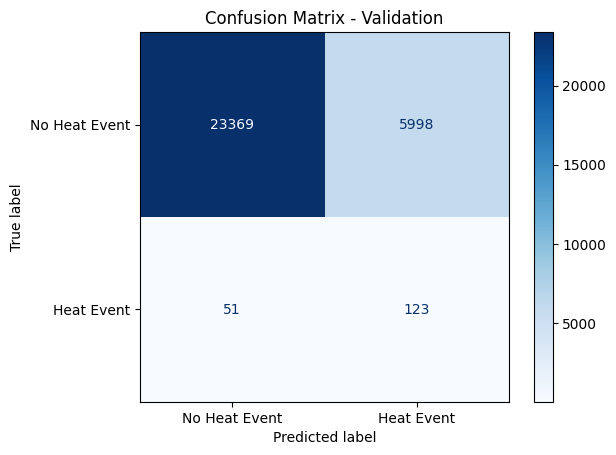

In [11]:
baseline_val_pred, baseline_val_proba = evaluate_model(
    baseline_model,
    X_val,
    y_val,
    dataset_name="Validation"
)

In [12]:
# To make tuning faster on a large dataset, use a smaller stratified sample of the training set
X_train_tune, _, y_train_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.10,   # increase to 0.20 if your machine can handle it
    random_state=42,
    stratify=y_train
)

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_distributions = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [3, 5, 7, 10, 15, None],
    "model__min_samples_split": [2, 10, 25, 50, 100],
    "model__min_samples_leaf": [1, 5, 10, 20, 50],
    "model__ccp_alpha": [0.0, 0.0001, 0.001, 0.005]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=15,              # reduce if runtime is too long
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_tune, y_train_tune)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validated score:")
print(random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__criterion': 'entropy', 'model__ccp_alpha': 0.001}

Best cross-validated score:
0.023040117409662223


===== Validation (Tuned Model) Evaluation =====
              precision    recall  f1-score   support

           0     0.9955    0.8853    0.9372     29367
           1     0.0166    0.3276    0.0317       174

    accuracy                         0.8820     29541
   macro avg     0.5061    0.6064    0.4844     29541
weighted avg     0.9898    0.8820    0.9318     29541

ROC-AUC: 0.6161
PR-AUC:  0.0183


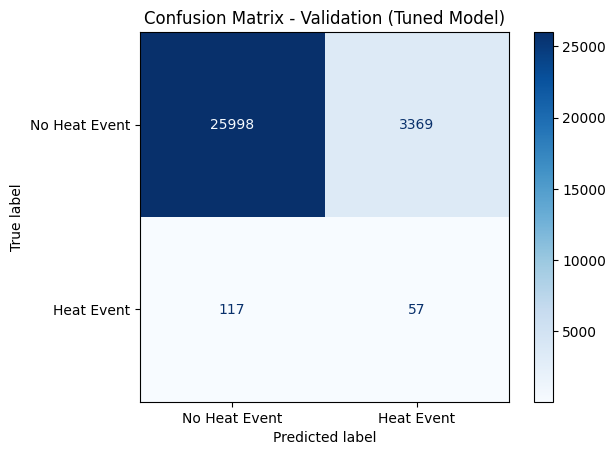

In [13]:
best_model = random_search.best_estimator_

tuned_val_pred, tuned_val_proba = evaluate_model(
    best_model,
    X_val,
    y_val,
    dataset_name="Validation (Tuned Model)"
)

In [14]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_model = random_search.best_estimator_
final_model.fit(X_train_full, y_train_full)

print("Final model trained on train + validation data.")

Final model trained on train + validation data.


===== Test Evaluation =====
              precision    recall  f1-score   support

           0     0.9991    0.8067    0.8926     29367
           1     0.0264    0.8800    0.0513       175

    accuracy                         0.8071     29542
   macro avg     0.5128    0.8433    0.4720     29542
weighted avg     0.9934    0.8071    0.8877     29542

ROC-AUC: 0.8874
PR-AUC:  0.0580


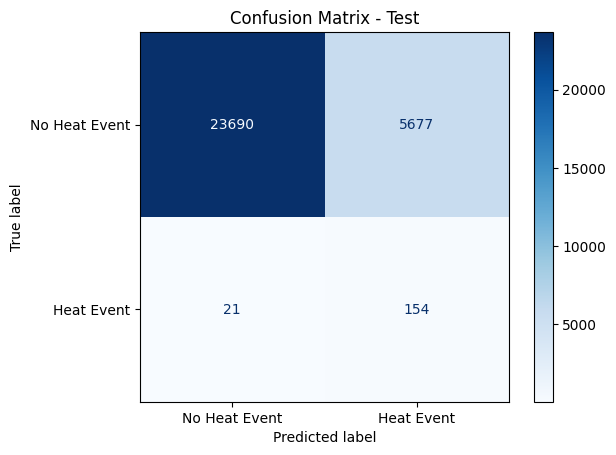

In [15]:
test_pred, test_proba = evaluate_model(
    final_model,
    X_test,
    y_test,
    dataset_name="Test"
)

In [16]:
# Get fitted tree and processed feature names
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_tree = final_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_tree.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(importance_df.head(20))

,feature,importance
17,num__dayofyear,0.197750
0,num__TMAX,0.159769
11,num__overall_score,0.115132
16,num__day,0.097431
14,num__year,0.090235
18,num__weekday,0.049616
13,num__pop_state_sum,0.045450
168,cat__state_WA,0.037285
5,num__p_nohsdp,0.028855
10,num__p_asthma,0.027899


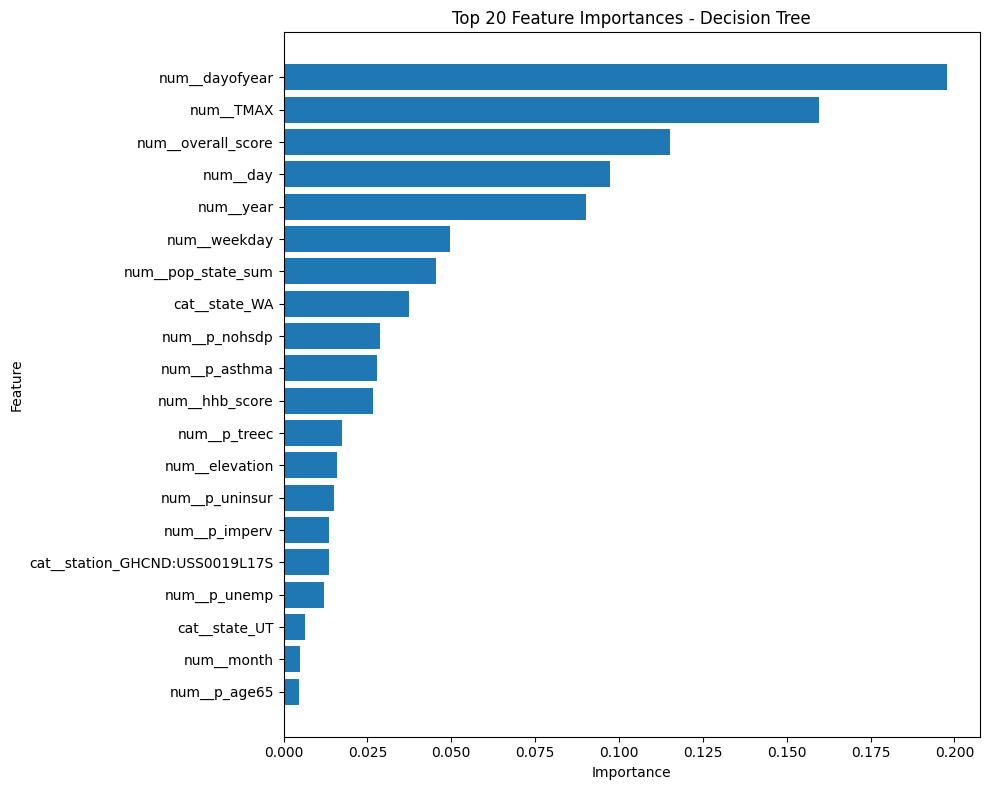

In [ ]:
top_n = 20
top_features = importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Decision Tree")
plt.tight_layout()
plt.savefig("../../website/resources/img/plots/trees_feature_importance.png")
plt.show()

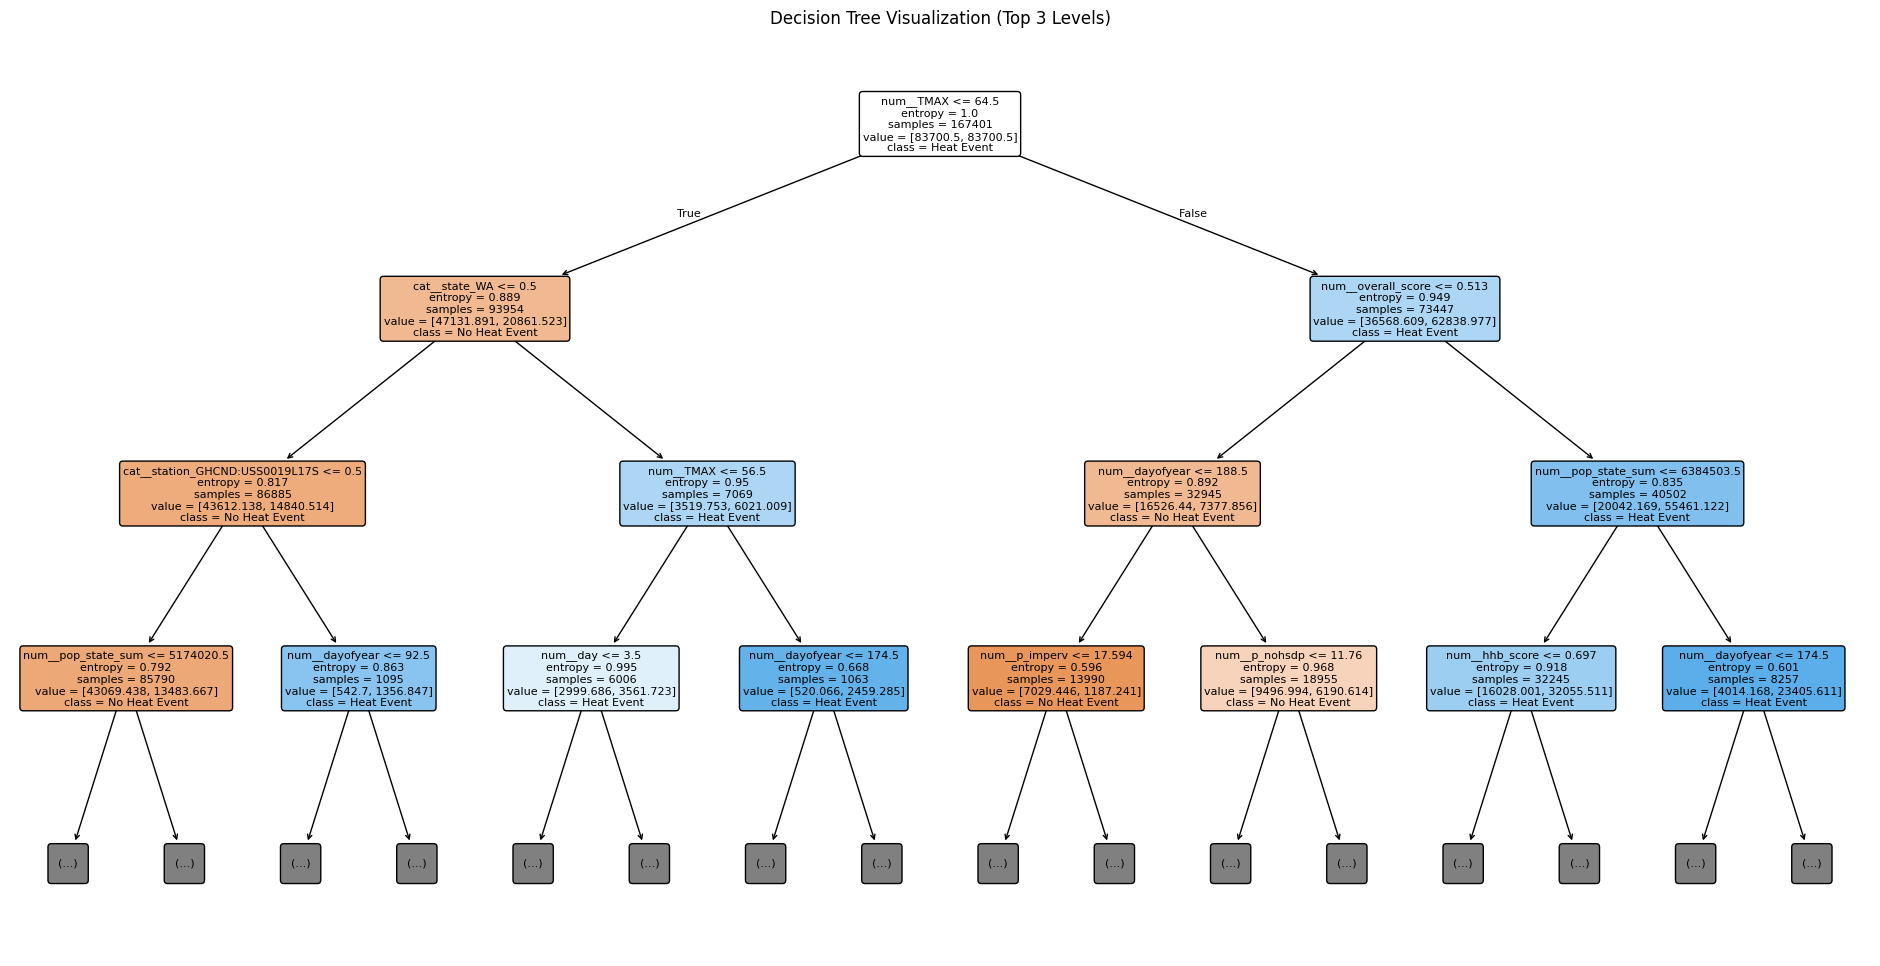

In [ ]:
plt.figure(figsize=(24, 12))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["No Heat Event", "Heat Event"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.savefig("../../website/resources/img/plots/trees_decision_tree.png")
plt.show()

For the decision tree model, preprocessing was essential because the raw dataset contained a mix of date, categorical, identifier, and numeric variables. The original file had 196,943 rows and 23 columns, and the target variable heat_related_any was extremely imbalanced, with only 1,162 positive cases (0.59%) and 195,781 negative cases (99.41%). To make the data usable for modeling, the date column was converted to a datetime format and expanded into new temporal features (year, month, day, dayofyear, weekday, and is_weekend) so the model could capture seasonality and calendar effects. The original date field was then dropped, and the id column was removed because it duplicated station. In addition, leakage-related variables such as heat_related_disaster_count, heat_related_area_count, heat_related_counties_affected, and disasters_count were excluded so the model would not learn from variables that directly reveal the outcome. After preprocessing, the model used 22 input features, including 20 numeric variables and 2 categorical variables (station and state). Although decision trees are often described as handling categorical data well conceptually, the scikit-learn implementation still requires numeric input, so station and state were one-hot encoded, while missing numeric values were imputed with the median and missing categorical values with the most frequent category.

The decision tree was chosen because it can model nonlinear relationships, works well with mixed feature types, and is easy to interpret through feature importance and tree visualization. A baseline tree with class_weight="balanced", max_depth=5, and min_samples_leaf=10 was first trained to address the severe class imbalance. On the validation set, it achieved 79.52% accuracy, 70.69% recall for the positive class, 0.7834 ROC-AUC, and 0.0238 PR-AUC, but its precision was only 0.0201, meaning it produced many false positives. Hyperparameter tuning with RandomizedSearchCV selected criterion='entropy', max_depth=10, min_samples_split=10, min_samples_leaf=1, and ccp_alpha=0.001, using average precision as the tuning metric because accuracy alone would be misleading on such an imbalanced dataset. After retraining the tuned model on the combined training and validation sets, the final test results were 80.71% accuracy, 88.00% recall, 0.0264 precision, 0.0513 F1-score, 0.8874 ROC-AUC, and 0.0580 PR-AUC. These results show that the model was relatively strong at detecting rare heat-related events but weak at making highly precise positive predictions. In other words, the decision tree is useful when the project prioritizes finding as many true heat-related cases as possible, but its low precision suggests that many flagged events are false alarms, which is a common challenge in highly imbalanced classification problems.